In [30]:
from mlxtend.frequent_patterns import apriori, association_rules
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np

In [31]:
ratings = pd.read_csv('ratings.csv')
movies = pd.read_csv('movies.csv')

db_merged = pd.merge(ratings, movies, on='movieId')
db_sort = db_merged[db_merged['rating'] >= 4.0]

print(f"size of a filtered database: {db_sort.shape}")
print(f"amount of unique movies: {db_sort['title'].nunique()}")
print(f"amount of unique users: {db_sort['userId'].nunique()}")

size of a filtered database: (48580, 6)
amount of unique movies: 6297
amount of unique users: 609


In [32]:
def encode(x):
    if x <= 0: return 0
    if x >= 1: return 1

matrix = (db_sort.groupby(['userId', 'title'])['rating'].count()
          .unstack().fillna(0))
matrix_sets = matrix.map(encode)
print(matrix_sets.head())

title   '71 (2014)  'Hellboy': The Seeds of Creation (2004)  \
userId                                                        
1                0                                        0   
2                0                                        0   
3                0                                        0   
4                0                                        0   
5                0                                        0   

title   'Salem's Lot (2004)  'Til There Was You (1997)  'burbs, The (1989)  \
userId                                                                       
1                         0                          0                   0   
2                         0                          0                   0   
3                         0                          0                   0   
4                         0                          0                   0   
5                         0                          0                   0   

title   (50

frequent itemsets count with different support threshold
min support: 0.05, found: 33189 itemsets
min support: 0.10, found: 863 itemsets
min support: 0.20, found: 43 itemsets
min support: 0.30, found: 6 itemsets

top 10 most popular movie combinations (support)
      support  \
93   0.449918   
40   0.408867   
83   0.400657   
96   0.369458   
68   0.364532   
103  0.330049   
38   0.293924   
90   0.287356   
279  0.275862   
104  0.275862   

                                                               itemsets  
93                        frozenset({Shawshank Redemption, The (1994)})  
40                                     frozenset({Forrest Gump (1994)})  
83                                     frozenset({Pulp Fiction (1994)})  
96                        frozenset({Silence of the Lambs, The (1991)})  
68                                      frozenset({Matrix, The (1999)})  
103              frozenset({Star Wars: Episode IV - A New Hope (1977)})  
38                              

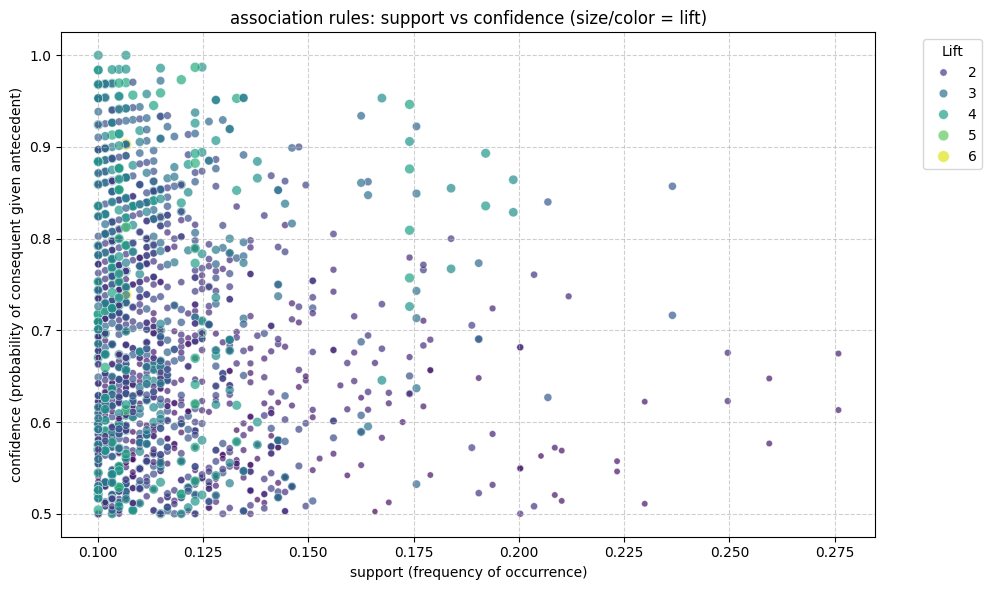

In [36]:
support_thresholds = [0.05, 0.1, 0.2, 0.3]
frequent_sets_dict = {}

print("frequent itemsets count with different support threshold")
for sup in support_thresholds:
    itemsets = apriori(matrix_sets.astype(bool), min_support=sup, use_colnames=True)
    frequent_sets_dict[sup] = itemsets
    print(f"min support: {sup:.2f}, found: {len(itemsets)} itemsets")

frequent_item_sets = frequent_sets_dict[0.1]

print(f"\ntop 10 most popular movie combinations (support)")
top_combinations = frequent_item_sets.sort_values(by='support', ascending=False).head(10)
print(top_combinations[['support', 'itemsets']])

if not top_combinations.empty:
    top_items = list(top_combinations.iloc[0]['itemsets'])
    print(f"\ninsight: the combination {top_items} is the most frequent, appearing in {top_combinations.iloc[0]['support']:.1%} of user profiles.")



rules = association_rules(frequent_item_sets, metric="confidence", min_threshold=0.5)

print("\ntop 10 association rules by lift")
top_rules = rules.sort_values(by='lift', ascending=False).head(10)

pd.set_option('display.max_colwidth', 100)
print(top_rules[['antecedents', 'consequents', 'support', 'confidence', 'lift']])

if not top_rules.empty:
    sample = top_rules.iloc[0]
    ant = list(sample['antecedents'])
    con = list(sample['consequents'])
    print(f"\nrule interpretation:")
    print(f"users who like {ant} are {sample['confidence']:.1%} likely to also like {con}.")
    print(f"a lift of {sample['lift']:.2f} indicates a strong positive association between these movies.")

plt.figure(figsize=(10, 6))
sns.scatterplot(data=rules, x="support", y="confidence",
    size="lift", hue="lift", palette="viridis", alpha=0.7)
plt.title("association rules: support vs confidence (size/color = lift)")
plt.xlabel("support (frequency of occurrence)")
plt.ylabel("confidence (probability of consequent given antecedent)")
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', title='Lift')
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()